In [ ]:
import json

print = __builtins__.print # Fix: Reassign print to the built-in print function
subjects_list = [] # Changed 'subject' to 'subjects_list' to hold all subjects
hours_list = []

print("Please enter your study subjects and hours for today:")
for i in range(3):
    current_subject = input(f"enter subject {i+1}: ") # Store input subject in a temporary variable
    hours = int(input(f"enter hours studied for {current_subject}: ")) # Convert hours to integer for calculations

    subjects_list.append(current_subject) # Append the current subject to the subjects_list
    hours_list.append(hours) # Append the hours to the hours_list

# Calculate daily summaries after all inputs are collected
total_daily_hours = sum(hours_list)

max_hours = max(hours_list)
max_index = hours_list.index(max_hours)

print(f"\nToday's most studied subject: {subjects_list[max_index]} ({max_hours} hours)")
print(f"Total hours studied today: {total_daily_hours} hours")

# Save input data to a temporary file for robust transfer between cells
temp_input_data = {
    'subjects_list': subjects_list,
    'hours_list': hours_list,
    'total_daily_hours': total_daily_hours
}
with open('temp_daily_input.json', 'w') as f:
    json.dump(temp_input_data, f, indent=4)
print("Today's input data saved temporarily to temp_daily_input.json")

Please enter your study subjects and hours for today:
enter subject 1: english
enter hours studied for english: 3
enter subject 2: math
enter hours studied for math: 3
enter subject 3: french
enter hours studied for french: 2

Today's most studied subject: english (3 hours)
Total hours studied today: 8 hours
Today's input data saved temporarily to temp_daily_input.json


In [ ]:
import json
import os
from datetime import date

historical_data_file = 'study_tracker_data.json'

# Load historical data or initialize an empty dictionary
if os.path.exists(historical_data_file):
    with open(historical_data_file, 'r') as f:
        historical_data = json.load(f)
else:
    historical_data = {} # Structure: { 'YYYY-MM-DD': { 'subject1': hours, 'subject2': hours }, ... }

In [ ]:
# Update historical data with today's study hours and save
import json
import os
from datetime import date

# Define your daily study goal (in hours) - ensure this is consistent or passed from a central config
# For robustness, we will assume daily_study_goal is available, or use a default.
# If daily_study_goal is not defined by now, it will default to 8 hours.
if 'daily_study_goal' not in locals():
    daily_study_goal = 8

# Ensure historical_data is loaded (re-loading for robustness in case cells are run out of order)
historical_data_file = 'study_tracker_data.json'
if os.path.exists(historical_data_file):
    with open(historical_data_file, 'r') as f:
        try:
            historical_data = json.load(f)
        except json.JSONDecodeError:
            historical_data = {}
else:
    historical_data = {}

today_date = str(date.today())

# Attempt to load subjects_list and hours_list from global scope or temporary file
if 'subjects_list' not in globals() or 'hours_list' not in globals() or not subjects_list or not hours_list:
    temp_input_file = 'temp_daily_input.json'
    if os.path.exists(temp_input_file):
        try:
            with open(temp_input_file, 'r') as f:
                temp_data = json.load(f)
            subjects_list = temp_data.get('subjects_list', [])
            hours_list = temp_data.get('hours_list', [])
            total_daily_hours = temp_data.get('total_daily_hours', 0)
            print(f"Loaded today's input data from {temp_input_file}.")
        except json.JSONDecodeError:
            print(f"Warning: Could not decode JSON from {temp_input_file}. Please ensure the daily input cell (KEQrbOSiBMZ1) is run first.")
            subjects_list = []
            hours_list = []
            total_daily_hours = 0
    else:
        print("Warning: 'subjects_list' or 'hours_list' not found and no temporary input file. Please ensure the daily input cell (KEQrbOSiBMZ1) is run before this cell to record today's study data.")
        subjects_list = []
        hours_list = []
        total_daily_hours = 0
else:
    # If already in globals, use existing values and ensure total_daily_hours is also updated if needed
    if 'total_daily_hours' not in globals():
        total_daily_hours = sum(hours_list)


daily_subject_hours = {}
if subjects_list and hours_list: # Only process if actual data exists
    for i in range(len(subjects_list)):
        subject = subjects_list[i]
        hours = hours_list[i]
        # If a subject is studied multiple times a day, sum the hours
        daily_subject_hours[subject] = daily_subject_hours.get(subject, 0) + hours

    # Determine if goal was achieved
    goal_achieved_today = total_daily_hours >= daily_study_goal

    # Calculate productivity score
    # Avoid division by zero if daily_study_goal is 0
    if daily_study_goal > 0:
        productivity_score_today = (total_daily_hours / daily_study_goal) * 100
    else:
        productivity_score_today = 0 # Cannot calculate if goal is 0

    # Store daily_subject_hours along with goal achievement and productivity in historical_data
    historical_data[today_date] = {
        "subjects": daily_subject_hours,
        "total_hours": total_daily_hours,
        "goal_achieved": goal_achieved_today,
        "productivity_score": productivity_score_today
    }

    with open(historical_data_file, 'w') as f:
        json.dump(historical_data, f, indent=4)

    print(f"Today's study data ({today_date}) saved to {historical_data_file}")
    print(f"Goal achieved today: {goal_achieved_today}")
    print(f"Today's productivity score: {productivity_score_today:.2f}%") # Fixed the '%)' to '%'
else:
    print(f"No study data recorded for today ({today_date}) because the input could not be retrieved.")

Today's study data (2026-05-20) saved to study_tracker_data.json
Goal achieved today: True
Today's productivity score: 100.00%


In [ ]:
# Define your daily study goal (in hours)
daily_study_goal = 8 # You can change this value

In [ ]:
import json
import os
from datetime import date

# Ensure daily_study_goal is defined, with a default if not already in scope
if 'daily_study_goal' not in globals():
    daily_study_goal = 8 # Default to 8 hours if not defined by c0589fda or another cell

# Attempt to load today's total daily hours from historical data
total_daily_hours = 0 # Default if no data is found
historical_data_file = 'study_tracker_data.json'

if os.path.exists(historical_data_file):
    try:
        with open(historical_data_file, 'r') as f:
            historical_data = json.load(f)
    except json.JSONDecodeError:
        historical_data = {} # Handle case where file is corrupt or empty JSON
        print(f"Warning: Could not decode JSON from {historical_data_file}. Assuming no historical data.")
else:
    historical_data = {} # No file found means no historical data
    print(f"Warning: {historical_data_file} not found. Assuming no historical data.")

today_date = str(date.today())
if today_date in historical_data and 'total_hours' in historical_data[today_date]:
    total_daily_hours = historical_data[today_date]['total_hours']
else:
    print(f"Note: No total daily hours found for today ({today_date}) in historical data. "
          "Please ensure the input and data saving cells (KEQrbOSiBMZ1, e337c61e) are run first to record data.")

# Daily Goal Achievement and Productivity Score

# Check if goal was achieved
if total_daily_hours >= daily_study_goal:
    print("Goal achieved! 🎉")
else:
    print("Goal not achieved! Keep going! 💪")

# Calculate daily productivity score
# Avoid division by zero if daily_study_goal is 0
if daily_study_goal > 0:
    productivity_score = (total_daily_hours / daily_study_goal) * 100
    print(f"\nDaily Productivity Rate: {productivity_score:.2f}%")
else:
    print("\nCannot calculate productivity score: Daily study goal is 0. Please set a positive goal.")


Goal achieved! 🎉

Daily Productivity Rate: 100.00%


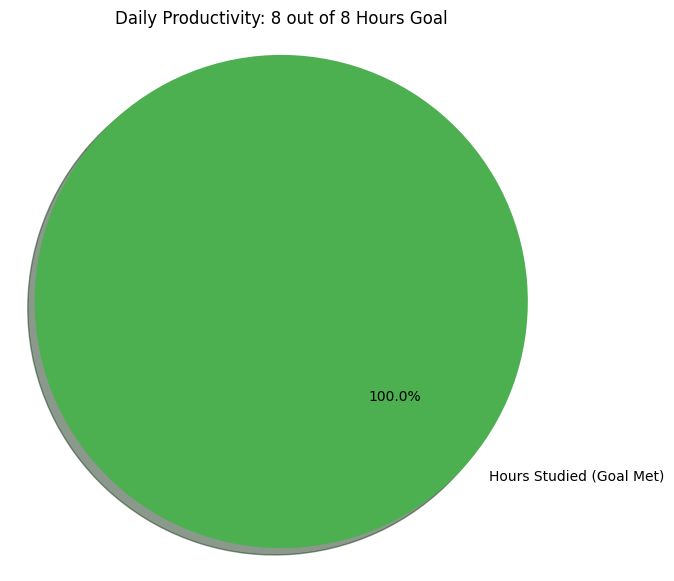

In [ ]:
# Visualize Daily Productivity with a Pie Chart
import matplotlib.pyplot as plt

# Data for the pie chart
actual_hours = total_daily_hours
remaining_hours = max(0, daily_study_goal - total_daily_hours)

# Labels and colors
labels = ['Hours Studied', 'Remaining Goal']
sizes = [actual_hours, remaining_hours]
colors = ['#4CAF50', '#FFCDD2'] # Green for studied, light red for remaining
explode = (0.1, 0)  # Explode the 'Hours Studied' slice if goal not met

if total_daily_hours < daily_study_goal:
    # If goal not met, adjust colors and sizes for a clearer representation of achievement vs. deficit
    # Or, you can choose to only show studied vs. remaining in goal context.
    # For simplicity, we'll keep the current approach of studied vs. what's needed to reach goal.
    # If total_daily_hours is > daily_study_goal, 'Remaining Goal' would be 0 or negative, which is not ideal for pie chart.
    # So, we'll make sure remaining_hours is at least 0.
    if actual_hours > daily_study_goal:
        labels = ['Hours Studied (Exceeded Goal)', 'Goal']
        sizes = [actual_hours - daily_study_goal, daily_study_goal] # Show excess and goal portion
        colors = ['#8BC34A', '#4CAF50'] # Lighter green for excess, green for goal
        explode = (0.1, 0)
    else:
        labels = ['Hours Studied', 'Hours to Goal']
        sizes = [actual_hours, daily_study_goal - actual_hours]
        colors = ['#4CAF50', '#FFCDD2']
        explode = (0.1, 0)
else:
    labels = ['Hours Studied (Goal Met)', ''] # Empty label for 0 remaining
    sizes = [actual_hours, 0]
    colors = ['#4CAF50', 'white'] # Only green for goal met, white for invisible slice
    explode = (0.05, 0) # Slightly explode for emphasis

# Filter out zero-sized slices if goal is exceeded or exactly met for 'Remaining Goal'
filtered_labels = []
filtered_sizes = []
filtered_colors = []
for i in range(len(sizes)):
    if sizes[i] > 0 or (sizes[i] == 0 and 'Goal Met' in labels[i]): # Keep 'Goal Met' label even if size is 0 for clarity if it's the only slice
        filtered_labels.append(labels[i])
        filtered_sizes.append(sizes[i])
        filtered_colors.append(colors[i])

if not filtered_sizes: # Handle case where all sizes are zero (e.g., initial state)
    filtered_labels = ['No Data']
    filtered_sizes = [1]
    filtered_colors = ['#CCCCCC']

plt.figure(figsize=(7, 7))
plt.pie(filtered_sizes, explode=explode[:len(filtered_sizes)], labels=filtered_labels, colors=filtered_colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title(f'Daily Productivity: {total_daily_hours} out of {daily_study_goal} Hours Goal')
plt.show()

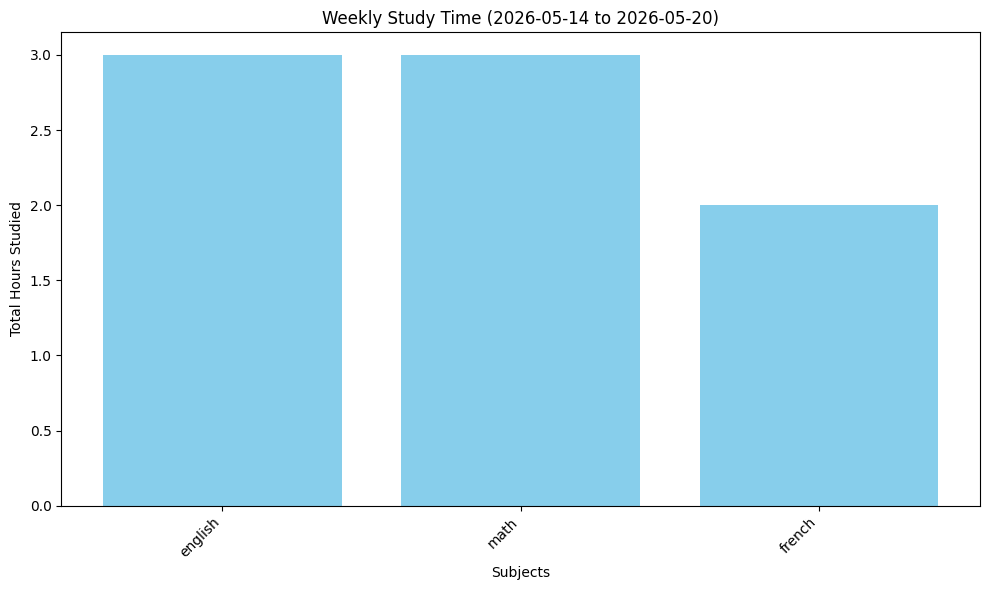


--- Summary of the Week ---
Great job! All subjects received good attention this week.


In [ ]:
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, date
import json
import os

# Ensure historical_data is loaded for weekly reports
historical_data_file = 'study_tracker_data.json'

# Load historical data or initialize an empty dictionary
if os.path.exists(historical_data_file):
    with open(historical_data_file, 'r') as f:
        try:
            historical_data = json.load(f)
        except json.JSONDecodeError:
            print(f"Warning: Could not decode JSON from {historical_data_file}. Initializing with empty data.")
            historical_data = {}
else:
    historical_data = {} # Structure: { 'YYYY-MM-DD': { 'subject1': hours, 'subject2': hours }, ... }


# Prepare data for weekly reports
subjects_weekly_hours = {}

# Get the last 7 days (including today)
end_date = date.today()
start_date = end_date - timedelta(days=6)

for d_str, daily_records in historical_data.items():
    d_obj = datetime.strptime(d_str, '%Y-%m-%d').date()
    if start_date <= d_obj <= end_date:
        # Access the 'subjects' dictionary within daily_records
        for subject, hours in daily_records.get('subjects', {}).items():
            subjects_weekly_hours[subject] = subjects_weekly_hours.get(subject, 0) + hours

if subjects_weekly_hours:
    # Sort subjects by total hours for better visualization
    sorted_subjects = sorted(subjects_weekly_hours.items(), key=lambda item: item[1], reverse=True)
    subjects = [item[0] for item in sorted_subjects]
    hours = [item[1] for item in sorted_subjects]

    plt.figure(figsize=(10, 6))
    plt.bar(subjects, hours, color='skyblue')
    plt.xlabel('Subjects')
    plt.ylabel('Total Hours Studied')
    plt.title(f'Weekly Study Time ({start_date} to {end_date})')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print("\n--- Summary of the Week ---")
    weak_subjects_summary = detect_weak_subject(subjects_weekly_hours)
    for summary_line in weak_subjects_summary:
        print(summary_line)

else:
    print(f"No study data found for the last 7 days ({start_date} to {end_date}).")

### Streak Calendar

This section generates a streak calendar to visualize your daily goal achievement. It highlights days where your study goal was met and calculates your current and longest streaks.

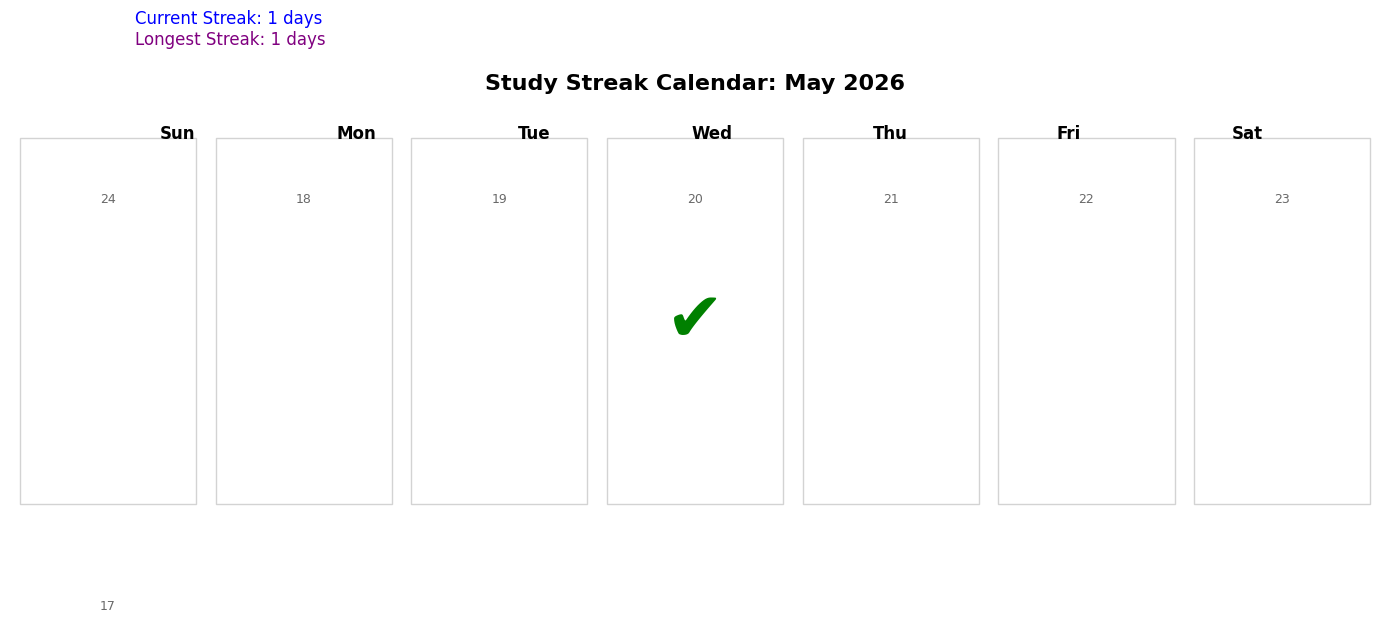

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import json
import os

# Ensure historical_data is loaded (if not already loaded by other cells)
historical_data_file = 'study_tracker_data.json'
if os.path.exists(historical_data_file):
    with open(historical_data_file, 'r') as f:
        try:
            historical_data = json.load(f)
        except json.JSONDecodeError:
            print(f"Warning: Could not decode JSON from {historical_data_file}. Initializing with empty data.")
            historical_data = {}
else:
    historical_data = {}

# Prepare data for the calendar
streak_data = {}
for d_str, data in historical_data.items():
    if 'goal_achieved' in data:
        streak_data[datetime.strptime(d_str, '%Y-%m-%d').date()] = data['goal_achieved']

if not streak_data:
    print("No goal achievement data available to generate streak calendar.")
else:
    # Sort dates to ensure correct streak calculation
    sorted_dates = sorted(streak_data.keys())

    # Calculate streaks
    current_streak = 0
    longest_streak = 0

    # Recalculate current streak to account for missing days correctly
    today = datetime.now().date()
    current_streak_tracker = 0
    longest_streak_tracker = 0
    last_successful_day = None

    # Iterate through all dates from the earliest recorded date to today
    all_calendar_dates = []
    if sorted_dates:
        current_day = sorted_dates[0]
        while current_day <= today:
            all_calendar_dates.append(current_day)
            current_day += timedelta(days=1)

    for current_date in all_calendar_dates:
        is_goal_achieved_for_day = streak_data.get(current_date, False) # Assume False if no record for the day

        if is_goal_achieved_for_day:
            current_streak_tracker += 1
            last_successful_day = current_date
        else:
            # If today is after the last successful day, and goal was not achieved today, reset current streak
            if last_successful_day and (current_date - last_successful_day).days > 1: # Gap in success
                current_streak_tracker = 0
            elif not last_successful_day and current_streak_tracker == 0: # Never started or already reset
                current_streak_tracker = 0
            # If today is the day after last successful day but goal wasn't met, reset streak
            elif last_successful_day and (current_date - last_successful_day).days == 1:
                current_streak_tracker = 0

        longest_streak_tracker = max(longest_streak_tracker, current_streak_tracker)

    # The final current_streak_tracker is the current streak ending today or earlier
    current_streak = current_streak_tracker
    longest_streak = longest_streak_tracker

    # Visualization
    fig, ax = plt.subplots(figsize=(14, 7)) # Increased figure size for better readability
    ax.set_facecolor('#f0f0f0') # Light gray background for the calendar area

    # Determine calendar grid boundaries
    min_recorded_date = min(sorted_dates)
    max_recorded_date = max(sorted_dates)

    # Calculate start_cal_date to begin on a Sunday for the first week containing min_recorded_date
    days_to_sunday = (min_recorded_date.weekday() + 1) % 7 # If Mon (0) -> 1, if Sun (6) -> 0
    start_cal_date = min_recorded_date - timedelta(days=days_to_sunday)

    # end_cal_date to end on a Saturday for the last week containing max_recorded_date
    days_to_saturday = (6 - max_recorded_date.weekday() + 7) % 7 # If Sat (5) -> 1, if Sun (6) -> 6
    end_cal_date = max_recorded_date + timedelta(days=days_to_saturday)

    calendar_dates = []
    current_cal_day = start_cal_date
    while current_cal_day <= end_cal_date:
        calendar_dates.append(current_cal_day)
        current_cal_day += timedelta(days=1)

    ax.set_yticks([]) # No y-axis ticks
    ax.set_xticks([]) # Remove x-ticks for a clean look, will draw day names with fig.text

    # Plot each day
    for d in calendar_dates:
        day_label = d.day
        # Adjust weekday index for Sunday = 0
        day_of_week_idx = (d.weekday() + 1) % 7
        row_idx = -(d - start_cal_date).days // 7

        # Draw a square border for each day to create a grid effect
        ax.add_patch(plt.Rectangle((day_of_week_idx - 0.45, row_idx - 0.45), 0.9, 0.9,
                                   facecolor='white', edgecolor='lightgrey', lw=1, zorder=1))

        if d in streak_data:
            if streak_data[d]: # Goal achieved - Green Checkmark
                ax.text(day_of_week_idx, row_idx, '✔', ha='center', va='center', color='green', fontsize=50, fontweight='bold', zorder=3)
            else: # Goal not achieved - Red X
                ax.text(day_of_week_idx, row_idx, '✖', ha='center', va='center', color='red', fontsize=50, fontweight='bold', zorder=3)

        # Display the day number (always, but make it subtle for past days without data if needed)
        # For now, display all day numbers clearly
        ax.text(day_of_week_idx, row_idx - 0.3, str(day_label), ha='center', va='center', color='dimgray', fontsize=9, zorder=4)


    ax.set_xlim(-0.5, 6.5)
    ax.set_ylim(min(row_idx for d in calendar_dates) - 0.5, max(row_idx for d in calendar_dates) + 0.5)
    ax.invert_yaxis() # Latest week at the top

    # Generate a dynamic title based on the date range displayed
    title_month_year = ''
    if min_recorded_date.year == max_recorded_date.year and min_recorded_date.month == max_recorded_date.month:
        title_month_year = min_recorded_date.strftime('%B %Y')
    elif min_recorded_date.year == max_recorded_date.year:
        title_month_year = f'{min_recorded_date.strftime('%b')} - {max_recorded_date.strftime('%b %Y')}'
    else:
        title_month_year = f'{min_recorded_date.strftime('%b %Y')} - {max_recorded_date.strftime('%b %Y')}'

    ax.set_title(f'Study Streak Calendar: {title_month_year}', fontsize=16, fontweight='bold', pad=20)

    # Keep plot clean by turning off axes (labels and ticks are removed)
    plt.axis('off')

    # Add day names using fig.text, relative to the figure, to bypass ax.axis('off')
    day_names = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
    # Calculate positions based on the axes' position within the figure
    ax_bbox = ax.get_position()
    # Adjusted to move higher, closer to the title and just above the boxes
    y_pos_day_names = ax_bbox.y1 - 0.100

    # Adjust horizontal spread for labels
    spread_factor = 1.15 # Increased spread for labels
    new_width_for_labels = ax_bbox.width * spread_factor
    new_start_x_for_labels = ax_bbox.x0 - (new_width_for_labels - ax_bbox.width) / 2 # Re-center the wider span

    x_positions = [new_start_x_for_labels + (i + 0.5) * new_width_for_labels / 7 for i in range(7)]

    for i, day_name in enumerate(day_names):
        fig.text(x_positions[i], y_pos_day_names, day_name, ha='center', va='bottom',
                 color='black', fontsize=12, fontweight='bold', transform=fig.transFigure)

    # Add streak information (positioned at the bottom or top for clarity)
    fig.text(0.1, 0.95, f'Current Streak: {current_streak} days', fontsize=12, color='blue', ha='left', transform=fig.transFigure)
    fig.text(0.1, 0.92, f'Longest Streak: {longest_streak} days', fontsize=12, color='purple', ha='left', transform=fig.transFigure)

    # Adjust layout to make space for titles and streak info, as well as the new fig.text day names
    plt.tight_layout(rect=[0, 0.05, 1, 0.9])
    plt.show()

In [ ]:
def calculate_productivity(total_hours, goal):
  return(total_hours/goal)*100

def detect_weak_subject(subjects_weekly_hours, threshold_factor=0.7):
  """
  Detects subjects with comparatively lower study attention for the week.

  Args:
    subjects_weekly_hours (dict): A dictionary mapping subject names to total hours studied for the week.
    threshold_factor (float): A factor (e.g., 0.7 for 70%) to determine if a subject's hours are below average.

  Returns:
    list: A list of strings, each containing a summary for a weak subject.
  """
  weak_subject_summaries = []

  if not subjects_weekly_hours:
    return ["No subject data available for weekly analysis."]

  total_subjects = len(subjects_weekly_hours)
  total_hours_studied = sum(subjects_weekly_hours.values())

  if total_subjects == 0 or total_hours_studied == 0:
    return ["Insufficient data to determine weak subjects for the week."]

  average_hours_per_subject = total_hours_studied / total_subjects
  weak_threshold = average_hours_per_subject * threshold_factor

  for subject, hours in subjects_weekly_hours.items():
    if hours < weak_threshold:
      # Provide a generic but actionable suggestion for now
      weak_subject_summaries.append(
          f"{subject} received comparatively lower study attention this week ({hours:.1f} hours). "
          f"Consider dedicating more time to this subject, perhaps by reviewing core concepts or tackling practice problems."
      )
  if not weak_subject_summaries:
    weak_subject_summaries.append("Great job! All subjects received good attention this week.")

  return weak_subject_summaries